# Full-Trace Analysis — Emotional vs Neutral

Analyze only E (emotional) and N (neutral) whole-trace observations from
`dataNEW/`. Each row represents one complete 20-prompt trace. Joy is excluded.
The four throttle features and methods follow the original fulltrace notebook.

Bonferroni correction covers **4 features × 1 condition pair = 4 tests**,
separately for Welch and Mann–Whitney. Raw and corrected p-values are shown.
This E–N-focused analysis was requested after inspecting the three-class results;
it is exploratory, not a newly prespecified confirmatory analysis. Tests treat
traces as independent; repeated runs on the same node may be dependent.


In [1]:
%matplotlib inline
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'dataNEW' / 'all_whole.csv').is_file())
DATA_DIR = BASE_DIR / 'dataNEW'
RESULTS_DIR = DATA_DIR / 'analysis_EN'
RESULTS_DIR.mkdir(exist_ok=True)

FEATURES = [
    'core_power.throttle__mean_rate',
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__slope',
]

SHORT = {f: f.split('__')[-1] for f in FEATURES}

SEED = 42

print('Configuration OK')
CONDITIONS = ['neutral', 'emotional']
PAIRS = list(combinations(CONDITIONS, 2))
CODES = {'neutral': 'N', 'emotional': 'E'}
COLORS = {'neutral': '#777777', 'emotional': '#C44E52'}

Configuration OK


## §1 — Load data

In [2]:
whole_csvs = sorted(p for p in DATA_DIR.glob('*_whole.csv') if p.name != 'all_whole.csv')
if not whole_csvs:
    raise ValueError(f'No whole-trace CSVs in {DATA_DIR}')
frames = [pd.read_csv(p) for p in whole_csvs]
if any(len(frame) != 1 for frame in frames):
    raise ValueError('Expected one row per individual whole-trace CSV')
df = pd.concat(frames, ignore_index=True)
excluded = df.loc[~df.condition.isin(CONDITIONS), 'condition'].value_counts()
print('Excluded conditions:', excluded.to_dict())
df = df.loc[df.condition.isin(CONDITIONS)].copy().reset_index(drop=True)
if df.run_label.duplicated().any():
    raise ValueError('Duplicate run labels')
if set(df.condition) != set(CONDITIONS):
    raise ValueError(f'Unexpected or missing conditions: {set(df.condition)}')
if not df['mode'].eq('whole_trace').all():
    raise ValueError('Expected whole-trace rows only')
missing_features = [f for f in FEATURES if f not in df]
if missing_features:
    raise ValueError(f'Missing features: {missing_features}')
if not np.isfinite(df[FEATURES].to_numpy()).all():
    raise ValueError('Nonfinite selected feature values')
combined = pd.read_csv(DATA_DIR / 'all_whole.csv')
combined = combined.loc[combined.condition.isin(CONDITIONS)].copy()
pd.testing.assert_frame_equal(
    df.sort_values('run_label').reset_index(drop=True),
    combined.sort_values('run_label').reset_index(drop=True),
)
counts = df.condition.value_counts().reindex(CONDITIONS)
print(f'Data: {DATA_DIR}')
print(counts.to_string())
print(f'{len(df)} unique whole traces; {len(FEATURES)} features; combined CSV verified')


Excluded conditions: {'joy': 27}
Data: /Users/rsalvi/Desktop/mccviahat/dataNEW
condition
neutral      20
emotional    20
40 unique whole traces; 4 features; combined CSV verified


## §2 — Per-feature univariate tests

Compare N–E for each of the four features using descriptive
statistics, Welch two-sample t-tests, two-sided Mann–Whitney U tests, and the
original notebook's absolute standardized mean difference (the denominator is
the square root of the mean of the two sample variances, labeled `cohens_d`).
Bonferroni correction uses 4 comparisons separately within each test family.
Plot stars use corrected Mann–Whitney p-values. Both test families are reported;
the correction does not combine them into one family.


In [3]:
results = []
for feat in FEATURES:
    for left, right in PAIRS:
        a = df.loc[df.condition == left, feat].dropna().values
        b = df.loc[df.condition == right, feat].dropna().values
        if len(a) < 2 or len(b) < 2:
            raise ValueError(f'Need at least two values for {feat}: {left}/{right}')
        a_mean, a_std = np.mean(a), np.std(a, ddof=1)
        b_mean, b_std = np.mean(b), np.std(b, ddof=1)
        pooled_std = np.sqrt((a_std**2 + b_std**2) / 2)
        t_stat, t_p = ttest_ind(a, b, equal_var=False)
        u_stat, mwu_p = mannwhitneyu(a, b, alternative='two-sided')
        results.append(dict(
            feature=SHORT[feat], left=left, right=right,
            pair=f'{CODES[left]}–{CODES[right]}',
            direction='↑' + CODES[left if a_mean > b_mean else right],
            left_mean=a_mean, left_std=a_std, right_mean=b_mean, right_std=b_std,
            cohens_d=abs(a_mean-b_mean)/pooled_std if pooled_std > 0 else np.nan,
            t_stat=t_stat, t_p=t_p, U=u_stat, mwu_p=mwu_p))
res_df = pd.DataFrame(results)
n_tests = len(results)
res_df['t_p_corr'] = (res_df['t_p'] * n_tests).clip(upper=1.0)
res_df['mwu_p_corr'] = (res_df['mwu_p'] * n_tests).clip(upper=1.0)
print(f'Per-feature tests ({counts.to_dict()}, Bonferroni k={n_tests})')
print(res_df.to_string(index=False))
res_df.to_csv(RESULTS_DIR / 'pairwise_tests.csv', index=False)


Per-feature tests ({'neutral': 20, 'emotional': 20}, Bonferroni k=4)
         feature    left     right pair direction    left_mean     left_std   right_mean    right_std  cohens_d    t_stat      t_p     U    mwu_p  t_p_corr  mwu_p_corr
       mean_rate neutral emotional  N–E        ↑E 1.138559e+09 6.541990e+07 1.178117e+09 5.580286e+07  0.650610 -2.057410 0.046731 101.0 0.007712  0.186922    0.030847
        variance neutral emotional  N–E        ↑E 3.616646e+13 8.533050e+12 3.709028e+13 8.520665e+12  0.108342 -0.342608 0.733781 190.0 0.797197  1.000000    1.000000
spectral_entropy neutral emotional  N–E        ↑E 9.054834e-01 2.397043e-02 9.187168e-01 1.859499e-02  0.616891 -1.950780 0.058947 136.0 0.085855  0.235790    0.343420
           slope neutral emotional  N–E        ↑N 1.222694e+01 6.923071e+00 1.174874e+01 4.565787e+00  0.081548  0.257877 0.798108 184.0 0.675014  1.000000    1.000000


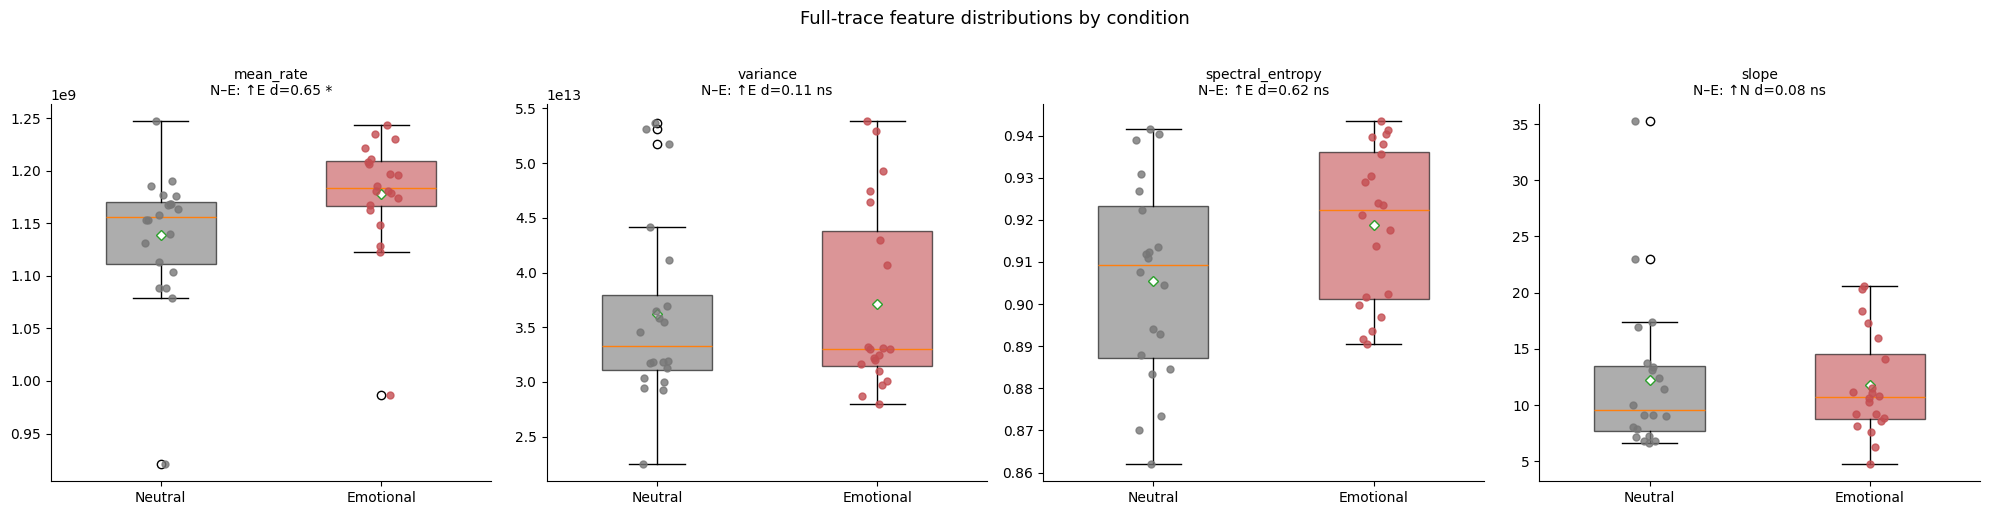

In [4]:
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(5 * n_feat, 5), squeeze=False)
rng_j = np.random.default_rng(SEED)
for ax, feat in zip(axes[0], FEATURES):
    groups = [df.loc[df.condition == c, feat].dropna().values for c in CONDITIONS]
    positions = np.arange(len(CONDITIONS))
    bp = ax.boxplot(groups, positions=positions, widths=0.5, patch_artist=True,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=5))
    for pos, cond, vals, box in zip(positions, CONDITIONS, groups, bp['boxes']):
        box.set_facecolor(COLORS[cond])
        box.set_alpha(0.6)
        ax.scatter(pos + rng_j.uniform(-0.08, 0.08, len(vals)), vals,
                   color=COLORS[cond], s=25, zorder=5, alpha=0.8)
    annotations = []
    for _, r in res_df[res_df.feature == SHORT[feat]].iterrows():
        sig = '***' if r.mwu_p_corr < 0.001 else '**' if r.mwu_p_corr < 0.01 else '*' if r.mwu_p_corr < 0.05 else 'ns'
        annotations.append(f'{r.pair}: {r.direction} d={r.cohens_d:.2f} {sig}')
    ax.set_title(SHORT[feat] + '\n' + '\n'.join(annotations), fontsize=10)
    ax.set_xticks(positions)
    ax.set_xticklabels([c.title() for c in CONDITIONS])
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Full-trace feature distributions by condition', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §2b — Per-feature intra/inter group distances

For each feature and condition pair, compute mean within-group distances, mean cross-condition distance, and the inter/intra ratio using the same unique within-group pairs and all cross-group pairs as before.

In [5]:
dist_1d_results = []
for feat in FEATURES:
    for left, right in PAIRS:
        a = df.loc[df.condition == left, feat].dropna().values
        b = df.loc[df.condition == right, feat].dropna().values
        intra_a = np.array([abs(x-y) for x, y in combinations(a, 2)])
        intra_b = np.array([abs(x-y) for x, y in combinations(b, 2)])
        inter = np.abs(a[:, None] - b[None, :]).ravel()
        mean_intra = np.concatenate([intra_a, intra_b]).mean()
        r = res_df[(res_df.feature == SHORT[feat]) & (res_df.left == left) & (res_df.right == right)].iloc[0]
        dist_1d_results.append(dict(
            feature=SHORT[feat], left=left, right=right, pair=r.pair, direction=r.direction,
            intra_left=intra_a.mean(), intra_right=intra_b.mean(),
            intra_avg=mean_intra, inter=inter.mean(),
            ratio=inter.mean()/mean_intra if mean_intra > 0 else np.nan))
dist_1d_df = pd.DataFrame(dist_1d_results)
print(dist_1d_df.to_string(index=False))
print('Inter/Intra > 1: cross-condition pairs are farther apart on average.')
print('Inter/Intra ≈ 1: similar mean within- and cross-condition distances.')
dist_1d_df.to_csv(RESULTS_DIR / 'feature_distances.csv', index=False)


         feature    left     right pair direction   intra_left  intra_right    intra_avg        inter    ratio
       mean_rate neutral emotional  N–E        ↑E 6.531123e+07 5.548578e+07 6.039851e+07 6.806691e+07 1.126964
        variance neutral emotional  N–E        ↑E 9.235180e+12 9.270381e+12 9.252780e+12 8.958595e+12 0.968206
spectral_entropy neutral emotional  N–E        ↑E 2.813269e-02 2.173670e-02 2.493470e-02 2.634401e-02 1.056520
           slope neutral emotional  N–E        ↑N 6.757011e+00 5.149549e+00 5.953280e+00 5.800967e+00 0.974415
Inter/Intra > 1: cross-condition pairs are farther apart on average.
Inter/Intra ≈ 1: similar mean within- and cross-condition distances.


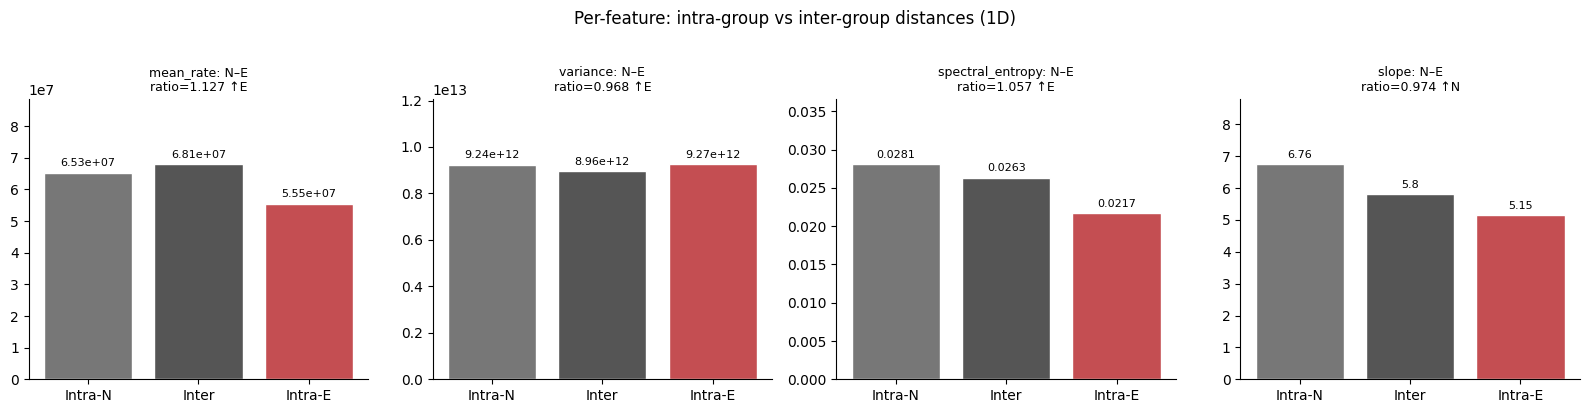

In [6]:
# Same intra/inter bars, with a row for each condition pair.
fig, axes = plt.subplots(len(PAIRS), len(FEATURES),
                         figsize=(4 * len(FEATURES), 4 * len(PAIRS)), squeeze=False)
for row_idx, (left, right) in enumerate(PAIRS):
    for col_idx, feat in enumerate(FEATURES):
        ax = axes[row_idx, col_idx]
        row = dist_1d_df[(dist_1d_df.feature == SHORT[feat]) &
                         (dist_1d_df.left == left) & (dist_1d_df.right == right)].iloc[0]
        vals = [row.intra_left, row.inter, row.intra_right]
        bars = ax.bar(range(3), vals, color=[COLORS[left], '#555555', COLORS[right]], edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, val+max(vals)*0.02,
                    f'{val:.3g}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(range(3))
        ax.set_xticklabels([f'Intra-{CODES[left]}', 'Inter', f'Intra-{CODES[right]}'])
        ax.set_title(f'{row.feature}: {row.pair}\nratio={row.ratio:.3f} {row.direction}', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(0, max(vals)*1.3 if max(vals) > 0 else 1)
fig.suptitle('Per-feature: intra-group vs inter-group distances (1D)', y=1.02)
plt.tight_layout()
plt.show()

## §4 — Summary

In [7]:
print('FULL-TRACE ANALYSIS SUMMARY')
print('Traces: ' + ', '.join(f'{counts[c]} {c}' for c in CONDITIONS))
print(f'Features: {len(FEATURES)}')
print('PER-FEATURE RESULTS (Bonferroni-corrected):')
print(res_df[['feature', 'pair', 'direction', 'cohens_d', 't_p_corr', 'mwu_p_corr']].to_string(index=False))
print('PER-FEATURE DISTANCE RATIOS (inter/intra):')
print(dist_1d_df[['feature', 'pair', 'ratio', 'direction']].to_string(index=False))
print('Significant corrected Mann–Whitney comparisons:')
print(res_df.loc[res_df.mwu_p_corr < 0.05, ['feature', 'pair', 'direction', 'mwu_p_corr']].to_string(index=False))
print('E–N-only exploratory analysis: Bonferroni k=4 per test family.')


FULL-TRACE ANALYSIS SUMMARY
Traces: 20 neutral, 20 emotional
Features: 4
PER-FEATURE RESULTS (Bonferroni-corrected):
         feature pair direction  cohens_d  t_p_corr  mwu_p_corr
       mean_rate  N–E        ↑E  0.650610  0.186922    0.030847
        variance  N–E        ↑E  0.108342  1.000000    1.000000
spectral_entropy  N–E        ↑E  0.616891  0.235790    0.343420
           slope  N–E        ↑N  0.081548  1.000000    1.000000
PER-FEATURE DISTANCE RATIOS (inter/intra):
         feature pair    ratio direction
       mean_rate  N–E 1.126964        ↑E
        variance  N–E 0.968206        ↑E
spectral_entropy  N–E 1.056520        ↑E
           slope  N–E 0.974415        ↑N
Significant corrected Mann–Whitney comparisons:
  feature pair direction  mwu_p_corr
mean_rate  N–E        ↑E    0.030847
E–N-only exploratory analysis: Bonferroni k=4 per test family.


## Prompt TTR analysis

Word-level type/token ratio uses lowercase whitespace tokens from
`independentN.json` and `independentE.json`. This retains
the original notebook's equal-variance t-test and two-sided Mann–Whitney test.
TTR depends on text length; this supplementary check does not adjust hardware
features or establish absence of workload confounding.


In [8]:
import json

def ttr(text):
    tokens = text.lower().split()
    return len(set(tokens)) / len(tokens) if tokens else 0

ttr_groups = {}
for cond in CONDITIONS:
    path = BASE_DIR / 'prompts' / '20base' / f'independent{CODES[cond]}.json'
    prompts = json.loads(path.read_text())
    ttr_groups[cond] = [ttr(p['instructions']) for p in prompts]
print('Type-to-Token Ratio (word-level)')
for cond, vals in ttr_groups.items():
    print(f'{cond.title():10s} n={len(vals):3d} mean={np.mean(vals):.4f} std={np.std(vals):.4f}')
ttr_results = []
for left, right in PAIRS:
    t, p_t = ttest_ind(ttr_groups[left], ttr_groups[right])
    u, p_u = mannwhitneyu(ttr_groups[left], ttr_groups[right], alternative='two-sided')
    ttr_results.append(dict(pair=f'{CODES[left]}–{CODES[right]}', t=t, t_p=p_t, U=u, mwu_p=p_u,
                            t_p_corr=min(p_t*len(PAIRS), 1), mwu_p_corr=min(p_u*len(PAIRS), 1)))
ttr_df = pd.DataFrame(ttr_results)
print(ttr_df.to_string(index=False))
ttr_df.to_csv(RESULTS_DIR / 'prompt_ttr_tests.csv', index=False)
print('Corrected TTR p-values use Bonferroni across the single E–N pair (multiplier 1), separately for each test family.')

Type-to-Token Ratio (word-level)
Neutral    n= 20 mean=0.6044 std=0.0367
Emotional  n= 20 mean=0.6723 std=0.0398
pair         t      t_p    U   mwu_p  t_p_corr  mwu_p_corr
 N–E -5.469825 0.000003 42.0 0.00002  0.000003     0.00002
Corrected TTR p-values use Bonferroni across the single E–N pair (multiplier 1), separately for each test family.
